<a href="https://colab.research.google.com/github/mems250005042/GDG-problem-statement/blob/main/Live_Data_Integeration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
socket="wss://data.tradingview.com/socket.io/websocket"
import json
from websocket import create_connection
import pandas as pd

ws=create_connection(socket)

def create_msg(ws , func , arg):
  ms=json.dumps({"m" : func , "p": arg})
  msg="~m~" + str(len(ms)) + "~m~" +ms
  ws.send(msg)

create_msg(ws ,func="chart_create_session" , arg=["cs_zlTIYjpe1rVs",""])
create_msg(ws , func="resolve_symbol" , arg=["cs_zlTIYjpe1rVs","sds_sym_1","={\"session\":\"extended\",\"symbol\":\"NASDAQ:APP\"}"])
create_msg(ws , func="create_series" , arg=["cs_zlTIYjpe1rVs","sds_1","s1","sds_sym_1","1",100,"LASTSESSION"])

def format_data(data):
  start=data.find('"s":[')
  end=data.find(',"ns":')
  final_data=json.loads(data[start + 4:end])

  fdata=[]
  for item in final_data:
    fdata.append(item["v"])
  df=pd.DataFrame(fdata)
  columns=["timestamp" , "open" , "high" , "low" , "close" , "volume"]
  df=pd.DataFrame(fdata , columns=columns)
  return df


while True:
  response=ws.recv()
  print(response)
  print("/n")
  if "series_completed" in response:
    break
df= format_data(response)



~m~293~m~{"session_id":"0.7042.7706_wdc2-charts-free-4-tvbs-asfxi-4","timestamp":1769618709,"timestampMs":1769618709914,"release":"release_208-95","studies_metadata_hash":"a4e3b51549a4a9bf7b6d7ab2fc666e7a73134787","auth_scheme_vsn":2,"protocol":"json","via":"23.105.175.152:443","javastudies":["3.66"]}
/n
~m~95~m~{"m":"series_loading","p":["cs_zlTIYjpe1rVs","sds_1","s1"],"t":1769618710,"t_ms":1769618710028}~m~4895~m~{"m":"symbol_resolved","p":["cs_zlTIYjpe1rVs","sds_sym_1",{"source2":{"country":"US","description":"Cboe One","exchange-type":"exchange","id":"BATS","name":"Cboe One","url":"https://markets.cboe.com/us/equities/overview/"},"currency_code":"USD","source_id":"BATS","session_holidays":"20000117,20000221,20000421,20000529,20000704,20000904,20001123,20001225,20010101,20010115,20010219,20010413,20010528,20010704,20010903,20011122,20011225,20020101,20020121,20020218,20020329,20020527,20020704,20020902,20021128,20021225,20030101,20030120,20030217,20030418,20030526,20030704,20030901,

In [2]:
df

,timestamp,open,high,low,close,volume
0,1.769611e+09,544.86,549.48,543.00,548.850,2459.0
1,1.769611e+09,549.65,549.65,540.98,541.965,4034.0
2,1.769611e+09,541.82,544.62,540.60,544.620,1685.0
3,1.769611e+09,544.95,546.14,542.95,544.000,3794.0
4,1.769611e+09,543.80,545.11,542.80,545.110,1111.0
...,...,...,...,...,...,...
131,1.769618e+09,550.53,550.77,550.48,550.480,141.0
132,1.769619e+09,550.71,550.71,550.10,550.460,199.0
133,1.769619e+09,550.56,550.59,550.13,550.130,96.0
134,1.769619e+09,550.35,550.67,549.64,549.640,686.0


In [3]:
df['timestamp']=pd.to_datetime(df['timestamp'],unit="s")
df.set_index('timestamp' ,inplace=True)
df=df.close
type(df) , df

(pandas.core.series.Series,
 timestamp
 2026-01-28 14:30:00    548.850
 2026-01-28 14:31:00    541.965
 2026-01-28 14:32:00    544.620
 2026-01-28 14:33:00    544.000
 2026-01-28 14:34:00    545.110
                         ...   
 2026-01-28 16:41:00    550.480
 2026-01-28 16:42:00    550.460
 2026-01-28 16:43:00    550.130
 2026-01-28 16:44:00    549.640
 2026-01-28 16:45:00    549.580
 Name: close, Length: 136, dtype: float64)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

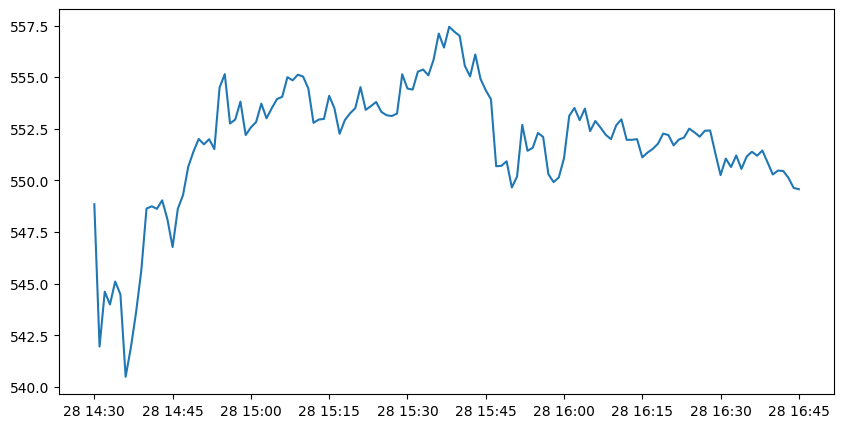

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df)

In [10]:
from statsmodels.tsa.stattools import adfuller
adfuller(df)

(np.float64(-3.062578274173211),
 np.float64(0.02944939183473952),
 3,
 132,
 {'1%': np.float64(-3.4808880719210005),
  '5%': np.float64(-2.8836966192225284),
  '10%': np.float64(-2.5785857598714417)},
 np.float64(312.59448407309014))

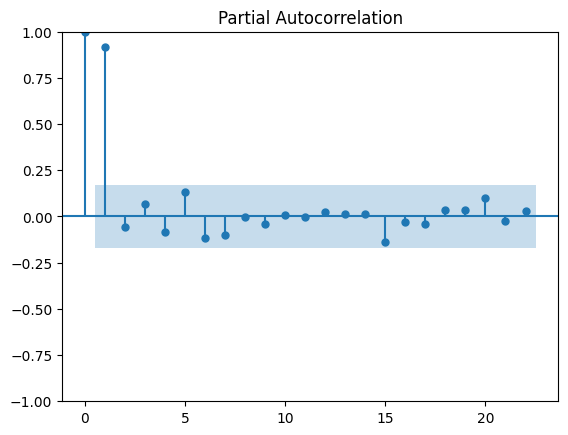

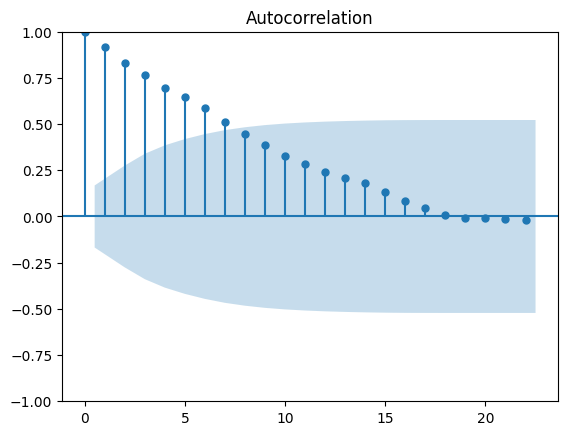

In [11]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf
pacf=plot_pacf(df)
acf=plot_acf(df)

In [12]:
df_diff=df.diff().dropna()

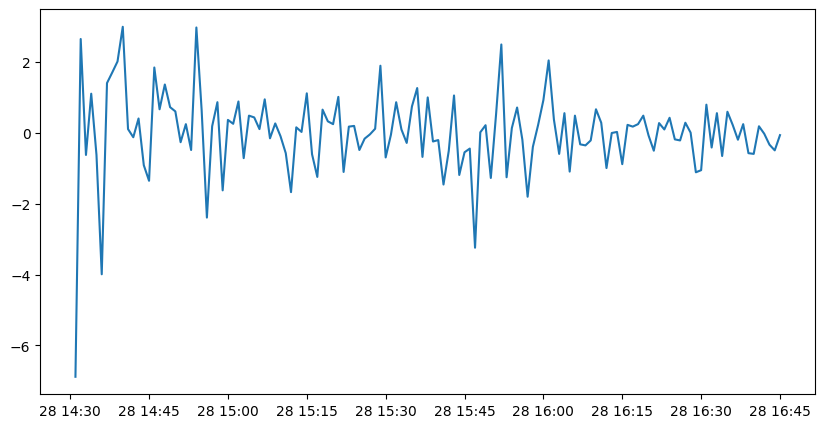

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df_diff)

In [14]:
#df = df.between_time("09:30", "16:00")


In [15]:
split=int(0.8*len(df))

train=df.iloc[:split]
test=df.iloc[split:]

from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(train , order=(7,1,7))
model_fit=model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found.

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  108
Model:                 ARIMA(7, 1, 7)   Log Likelihood                -172.538
Date:                Wed, 28 Jan 2026   AIC                            375.076
Time:                        16:45:45   BIC                            415.168
Sample:                    01-28-2026   HQIC                           391.329
                         - 01-28-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1429      1.227     -0.116      0.907      -2.548       2.262
ar.L2          0.7155      0.296      2.415      0.016       0.135       1.296
ar.L3         -0.3139      1.098     -0.286      0.7

In [16]:
test.shape , train.shape

((28,), (108,))

In [17]:
for i in range(1,8):
  model=ARIMA(train , order=(i,1,i))
  model_fit=model.fit()
  print(f"order : ({i},1,{i})" , "AIC :" , model_fit.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init

order : (1,1,1) AIC : 362.7311076806926
order : (2,1,2) AIC : 363.6322399377341


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be 

order : (3,1,3) AIC : 366.0718972469481


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros a

order : (5,1,5) AIC : 371.55268696273293


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros a

order : (6,1,6) AIC : 371.39839669015834
order : (7,1,7) AIC : 375.0759571956054


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
history=train.copy()
predictions=[]

for i in range(len(test)):
  # Changed order from (6,1,6) to (1,1,1) for better numerical stability
  model=ARIMA(history , order=(1,1,1))
  model_fit=model.fit()

  pred=model_fit.forecast().iloc[0]
  predictions.append(pred)

  history=pd.concat([history , test.iloc[i:i+1]])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init

In [20]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
mae=mean_absolute_error(test, predictions)
rmse=np.sqrt(mean_squared_error(test , predictions))
print(f"MAE : " , mae)
print(f" RMSE :" , rmse)

MAE :  0.3922852492262052
 RMSE : 0.4873872948964391


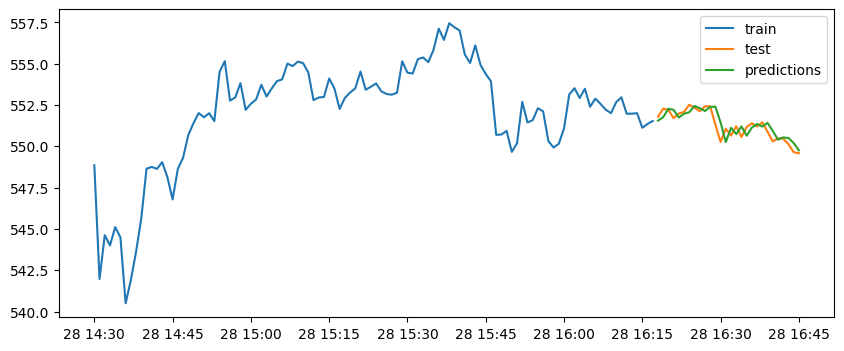

In [21]:
plt.figure(figsize=(10,4))
plt.plot(train.index , train , label="train")
plt.plot(test.index , test ,label="test")
plt.plot(test.index , predictions , label="predictions")
plt.legend()

In [24]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(df, order=(1,1,1))
model_fit=model.fit()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)


In [26]:
def update_df(df,candle):
  ts=pd.to_datetime(candle['timestamp'],unit="s").floor("min")#prevents duplicate rows for same candle

  df.loc[ts , "close"]=candle["close"]
  df=df.sort_index#always keep time order

  return df

In [27]:
def connect_tv():
  socket="wss://data.tradingview.com/socket.io/websocket"
  ws=create_connection(socket)


  create_msg(ws ,func="chart_create_session" , arg=["cs_zlTIYjpe1rVs",""])
  create_msg(ws , func="resolve_symbol" , arg=["cs_zlTIYjpe1rVs","sds_sym_1","={\"session\":\"extended\",\"symbol\":\"NASDAQ:APP\"}"])
  create_msg(ws , func="create_series" , arg=["cs_zlTIYjpe1rVs","sds_1","s1","sds_sym_1","1",100,"LASTSESSION"])
  return ws

In [35]:
def parse_new_candle(msg):
    start = msg.find('"v":[')
    end = msg.find(']}')
    candle = json.loads(msg[start+5:end+1])
    return {
        'timestamp': candle[0],
        'open': candle[1],
        'high': candle[2],
        'low': candle[3],
        'close': candle[4],
        'volume': candle[5]
    }


In [36]:
from websocket import create_connection , WebSocketConnectionClosedException
while True:
  try:
    msg=ws.recv()
    if "series_update" in msg:
      candle=parse_new_candle(msg)
      df=update_df(df, candle)
      df=df.tail(300)

      model=ARIMA(df["close"] , order=(1,1,1))
      model_fit=model.fit()
      next_forecast=model_fit.forecast()[0]

      print("Last close" , df.iloc[-1])
      print("Next minute prediction:", next_forecast)
  except WebSocketConnectionClosedException:
    print("WebSocket connection closed. Reconnecting...")
    ws = connect_tv()

    continue


WebSocket connection closed. Reconnecting...
WebSocket connection closed. Reconnecting...


KeyboardInterrupt: 

In [ ]:
#It's not giving values , kept saying websocket connection closed . reconnecting